In [1]:
import torch
from torch.utils.data import random_split
from torch.nn import functional as F
import numpy as np
from matplotlib import pyplot as plt
from xaikd import models, datasets, utils, attributors

from xaikd.utils import metrics

import pandas as pd

from tqdm import tqdm

In [2]:
DEVICE = utils.get_device()

In [3]:
model = models.get_trained_model("cifar100-resnet18-v1")
model.to(DEVICE)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

In [4]:
dataset = datasets.construct("cifar100")

In [5]:
PERCENTAGE_TRAINING_DATA = 1.0

In [6]:
ds_train = dataset.create_subset(train_split=True)

if PERCENTAGE_TRAINING_DATA < 1.0:
    rng = torch.Generator()
    rng.manual_seed(1)

    ds_train, _ = random_split(ds_train, [PERCENTAGE_TRAINING_DATA, 1-PERCENTAGE_TRAINING_DATA])

dl_train = datasets.build_dataloader(ds_train, shuffle=False)
len(ds_train), len(dl_train)

(50000, 782)

In [7]:
ds_val = dataset.create_subset(train_split=False)
dl_val = datasets.build_dataloader(ds_val, shuffle=False)

In [8]:
def get_reference_statistics():
    row = dict()
    
    for label, dl in [
        ("train", dl_train),
        ("val", dl_val),
    ]:
        acc, xent = utils.metrics.accuracy(
            model=model,
            dataloader=dl,
            num_classes=dataset.num_classes,
            device=DEVICE
        )
                
        row[f"final-{label}-acc"] = acc
        row[f"final-{label}-xent"] = xent
    return row
reference_statistics = get_reference_statistics()
reference_statistics

{'final-train-acc': 0.9998000264167786,
 'final-train-xent': 0.0035322164185345173,
 'final-val-acc': 0.7764000296592712,
 'final-val-xent': 0.9118000864982605}

In [9]:
def estimate_pca_at_layer(layer):
    rng = np.random.default_rng(seed=1)
    
    arr_acc, _ = attributors.extract_activation_context(
        model=model,
        layer=layer,
        dataset=dataset,
        data_loader=dl_train,
        rng=rng,
        device=DEVICE,
        logit_modifier=attributors.WinningClassEvidence(num_classes=dataset.num_classes)
    )
    
    eigvals, eigvecs = np.linalg.eigh(arr_acc.T @ arr_acc)
    sorted_indices = np.argsort(-eigvals)
    eigvals = eigvals[sorted_indices]
    eigvecs = eigvecs[:, sorted_indices]
    
    return eigvecs

estimate_pca_at_layer("layer1")

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 782/782 [00:54<00:00, 14.36it/s]


layer1: output-dims=torch.Size([64, 32, 32])


array([[ 0.18833473, -0.28452468,  0.30073956, ...,  0.00236163,
         0.01626127, -0.00069649],
       [ 0.17445552,  0.02755062, -0.05820648, ...,  0.00202008,
        -0.00859973,  0.00225454],
       [ 0.16953465,  0.03387152, -0.02632518, ..., -0.03280723,
        -0.01974584,  0.00062699],
       ...,
       [ 0.05078164,  0.02405423,  0.02630913, ...,  0.00316265,
        -0.00137072, -0.00231392],
       [ 0.04978524,  0.00908967,  0.02634055, ..., -0.00267811,
         0.0020879 , -0.0010695 ],
       [ 0.17233919,  0.41115946, -0.13364878, ...,  0.02306584,
        -0.00390621, -0.00099227]], dtype=float32)

In [10]:
utils.metrics.accuracy?

Signature:
utils.metrics.accuracy(
    model: torch.nn.modules.module.Module,
    dataloader: torch.utils.data.dataloader.DataLoader,
    num_classes: int,
    device: str,
    verbose=False,
) -> Tuple[float, float]
Docstring:
_summary_

Args:
    model (nn.Module): _description_
    dataloader (DataLoader): _description_
    num_classes (int): _description_
    device (str): _description_
    verbose (bool, optional): _description_. Defaults to False.

Returns:
    acc: torch.Tensor
    xent: torch.Tensor
File:      ~/projects/xai-kd/xaikd/utils/metrics.py
Type:      function

In [11]:
torch.nn.Conv2d(in_channels=10, out_channels=2, kernel_size=3).weight.shape

torch.Size([2, 10, 3, 3])

In [12]:
def construct_fh(U):

    U = torch.from_numpy(U@U.T).unsqueeze(2).unsqueeze(3).to(DEVICE)
    def fh(mod, inp, out):
        return F.conv2d(out, U)

    return fh

    
def estimate_accuracy(layer):
    U = estimate_pca_at_layer(layer)

    d = U.shape[0]
    arr_ks = np.linspace(0, d, num=20).astype(int)

    arr_rows = []
    for k in tqdm(arr_ks, desc=f"layer={layer}"): 
        row = dict(layer=layer, k=k)

        Uk = U[:, :k]
        fh = construct_fh(Uk)
        
        for label, dl in [
            ("train", dl_train),
            ("val", dl_val),
        ]:
            try:

                hook = utils.interceptor.get_module(model, layer).register_forward_hook(fh)
                acc, xent = utils.metrics.accuracy(
                    model=model,
                    dataloader=dl,
                    num_classes=dataset.num_classes,
                    device=DEVICE
                )
            finally:
                if hook is not None:
                    hook.remove()
                    
            row[f"{label}-acc"] = acc
            row[f"{label}-xent"] = xent
    
        arr_rows.append(row)
    
    return pd.DataFrame(arr_rows)    

estimate_accuracy("layer1")

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 782/782 [00:55<00:00, 14.20it/s]


layer1: output-dims=torch.Size([64, 32, 32])


layer=layer1: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [02:35<00:00,  7.76s/it]


,layer,k,train-acc,train-xent,val-acc,val-xent
0,layer1,0,0.01000,5.555353,0.0100,5.555348
1,layer1,3,0.08912,5.596933,0.0870,5.650552
2,layer1,6,0.53364,2.047458,0.4275,2.729976
3,layer1,10,0.86976,0.528098,0.6352,1.565695
4,layer1,13,0.94580,0.218422,0.6952,1.269459
5,layer1,16,0.99888,0.013707,0.7576,0.985381
6,layer1,20,0.99976,0.004595,0.7740,0.925584
7,layer1,23,0.99978,0.004077,0.7748,0.920324
8,layer1,26,0.99978,0.003882,0.7751,0.916730
9,layer1,30,0.99978,0.003698,0.7759,0.915574


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 782/782 [00:54<00:00, 14.24it/s]


layer1: output-dims=torch.Size([64, 32, 32])


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 782/782 [00:53<00:00, 14.64it/s]


layer2: output-dims=torch.Size([128, 16, 16])


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 782/782 [00:51<00:00, 15.08it/s]


layer3: output-dims=torch.Size([256, 8, 8])


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 782/782 [00:52<00:00, 14.91it/s]


layer4: output-dims=torch.Size([512, 4, 4])


layer=layer4: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [02:37<00:00,  7.87s/it]


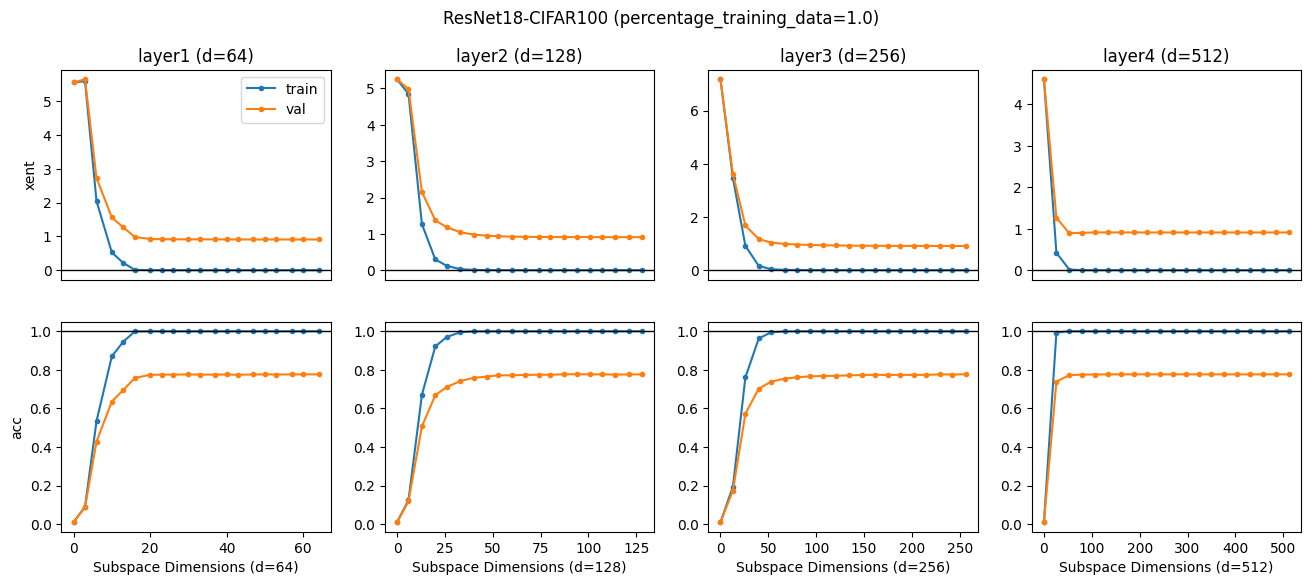

In [13]:
def viz():
    nrows = 2
    eps = 0.1
    arr_layers = ["layer1", "layer2", "layer3", "layer4"]
    ncols = len(arr_layers)
    plt.figure(figsize=(4*ncols, 3 *nrows))
    plt.suptitle(f"ResNet18-CIFAR100 (percentage_training_data={PERCENTAGE_TRAINING_DATA})")
    for lix, layer in enumerate(arr_layers):

        df_stats = estimate_accuracy(layer)
        d = df_stats.k.max()
        for cix, col in enumerate(["xent", "acc"]):
            plt.subplot(nrows, ncols, cix * ncols + lix + 1)

            for label in ["train", "val"]:
                plt.plot(
                    df_stats.k,
                    df_stats[f"{label}-{col}"],
                    label=label,
                    marker="."
                )

            plt.axhline(
                reference_statistics[f"final-train-{col}"], 
                ls="-", 
                lw=1, 
                color="k"
            )
            
        
            if cix == 0 and lix == 0:
                plt.legend()
            if cix == 0:
                plt.title(f"{layer} (d={d})")
                plt.xticks([])
            if lix == 0:
                plt.ylabel(col)
        
        plt.xlabel(f"Subspace Dimensions (d={d})")
viz()